In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mat73
import SensoriMotorPrediction.globals as gl

path_fig = 'figures'

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


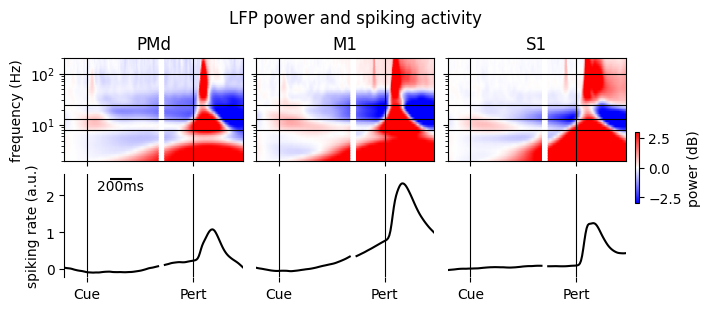

In [2]:
rois = ['PMd', 'M1', 'S1']
cfg = mat73.loadmat(os.path.join(gl.nhpDir, gl.lfpDir, 'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']

t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) + 5
t = np.concatenate((t_cue, t_pert))

lfp_list, spk_list, roi_list = [], [], []
for roi in rois:
    for mon in gl.monkey:
        for rec in gl.recordings_roi[mon][roi]:
            lfp_aligned = np.load(os.path.join(gl.nhpDir, gl.lfpDir, mon, f'lfp_aligned.avg.{roi}-{rec}.npy'))
            spk_aligned = np.load(os.path.join(gl.nhpDir, gl.spkDir, mon, f'spk_aligned.avg.{roi}-{rec}.npy'))
            lfp_list.append(lfp_aligned)
            spk_list.append(spk_aligned.mean(axis=-1))
            roi_list.append(roi)

lfp = np.stack(lfp_list)        # (roi, time, freq)
spk = np.stack(spk_list)        # (roi, time)
roi_labels = np.array(roi_list)

fig, axs = plt.subplots(2, len(rois), sharex='col', sharey='row', figsize=(7, 3), constrained_layout=True)

vmin, vmax = -3, 3

# boolean time masks (reproduce xarray's inclusive slice() selection on the time coordinate)
bs_mask = (t >= 0) & (t <= gl.cueIdx - 5)
cue_mask = (t >= 0) & (t <= gl.cuePost - 1)
pert_mask = (t >= gl.pertPre)

bs_lfp = lfp[:, bs_mask, :].mean(axis=1)        # (roi, freq)
bs_spk = spk[:, bs_mask].mean(axis=1)           # (roi,)
lfp_dB = 10 * np.log10(lfp / bs_lfp[:, None, :])
spk = spk - bs_spk[:, None]

for r, roi in enumerate(rois):
    ax = axs[:, r]
    roi_mask = roi_labels == roi
    ax[0].set_yscale('log')
    lfp_cue = lfp_dB[roi_mask][:, cue_mask, :].mean(axis=0)
    lfp_pert = lfp_dB[roi_mask][:, pert_mask, :].mean(axis=0)
    h1 = ax[0].pcolormesh(t_cue, foi, lfp_cue.T, vmin=vmin, vmax=vmax, cmap='bwr', shading='gouraud')
    h2 = ax[0].pcolormesh(t_pert, foi, lfp_pert.T, vmin=vmin, vmax=vmax, cmap='bwr', shading='gouraud')
    h1.set_rasterized(True)
    h2.set_rasterized(True)
    ax[0].axhline(8, color='k', lw='.8')
    ax[0].axhline(13, color='k', lw='.8')
    ax[0].axhline(25, color='k', lw='.8')
    ax[0].axhline(100, color='k', lw='.8')
    ax[0].axvline(gl.cueIdx, color='k', lw='.8')
    ax[0].axvline(gl.pertIdx, color='k', lw='.8')
    ax[0].set_xticks([gl.cueIdx, gl.pertIdx])
    ax[0].set_xticklabels(['Cue', 'Pert'])
    ax[0].set_title(roi)
    spk_cue = spk[roi_mask][:, cue_mask].mean(axis=0)
    spk_pert = spk[roi_mask][:, pert_mask].mean(axis=0)
    ax[1].plot(t_cue, spk_cue, color='k')
    ax[1].plot(t_pert, spk_pert, color='k')
    ax[1].spines[['right', 'top', 'bottom']].set_visible(False)
    ax[1].axvline(gl.cueIdx, color='k', lw='.8')
    ax[1].axvline(gl.pertIdx, color='k', lw='.8')
    ax[1].spines['left'].set_visible(False) if r > 0 else None
    ax[1].tick_params(left=False) if r > 0 else None

yline = axs[1, 0].get_ylim()[1]
axs[1, 0].hlines(yline, gl.cueIdx + 20, gl.cueIdx + 40, color='k', )
axs[1, 0].text(gl.cueIdx + 30, yline, '200ms', va='top', ha='center')

fig.colorbar(h1, ax=ax, label='power (dB)', fraction=0.02)
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('spiking rate (a.u.)')
fig.suptitle('LFP power and spiking activity')

fig.savefig(os.path.join('figures', f'lfp.desynchronisation.pdf'))

plt.show()